<a href="https://colab.research.google.com/github/ccoyso/Tapia/blob/main/SISTEMA_FOTOVOLTAICO_MALL_DE_IQUITOSvf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pvlib pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 30.3 MB/s eta 0:00:00


DISEÑO DE SISTEMA FOTOVOLTAICO - Iquitos, Perú

Ubicación:
  Latitud: -3.74°
  Longitud: -73.27°
  Altitud: 104 m
  Zona horaria: America/Lima

Superficie:
  Área total disponible: 20,637 m²
  Inclinación (tilt): 5°
  Azimuth: 0° (Norte)
  Relación DC/AC objetivo: 1.2

--------------------------------------------------------------------------------
DESCARGA DE DATOS CLIMÁTICOS
--------------------------------------------------------------------------------
Error descargando datos TMY: not enough values to unpack (expected 4, got 2)
Usando datos sintéticos para demostración...

--------------------------------------------------------------------------------
SELECCIÓN DE EQUIPOS - BASE DE DATOS SANDIA
--------------------------------------------------------------------------------

Módulos disponibles en base Sandia: 42
Inversores disponibles: 16

✓ MÓDULO SELECCIONADO: Entech_22X_Concentrator___1994_
  Potencia STC: 432.4 W
  Área: 3.180 m²
  Vmp: 20.2 V
  Imp: 21.44 A
  Voc: 24.6 V
  I

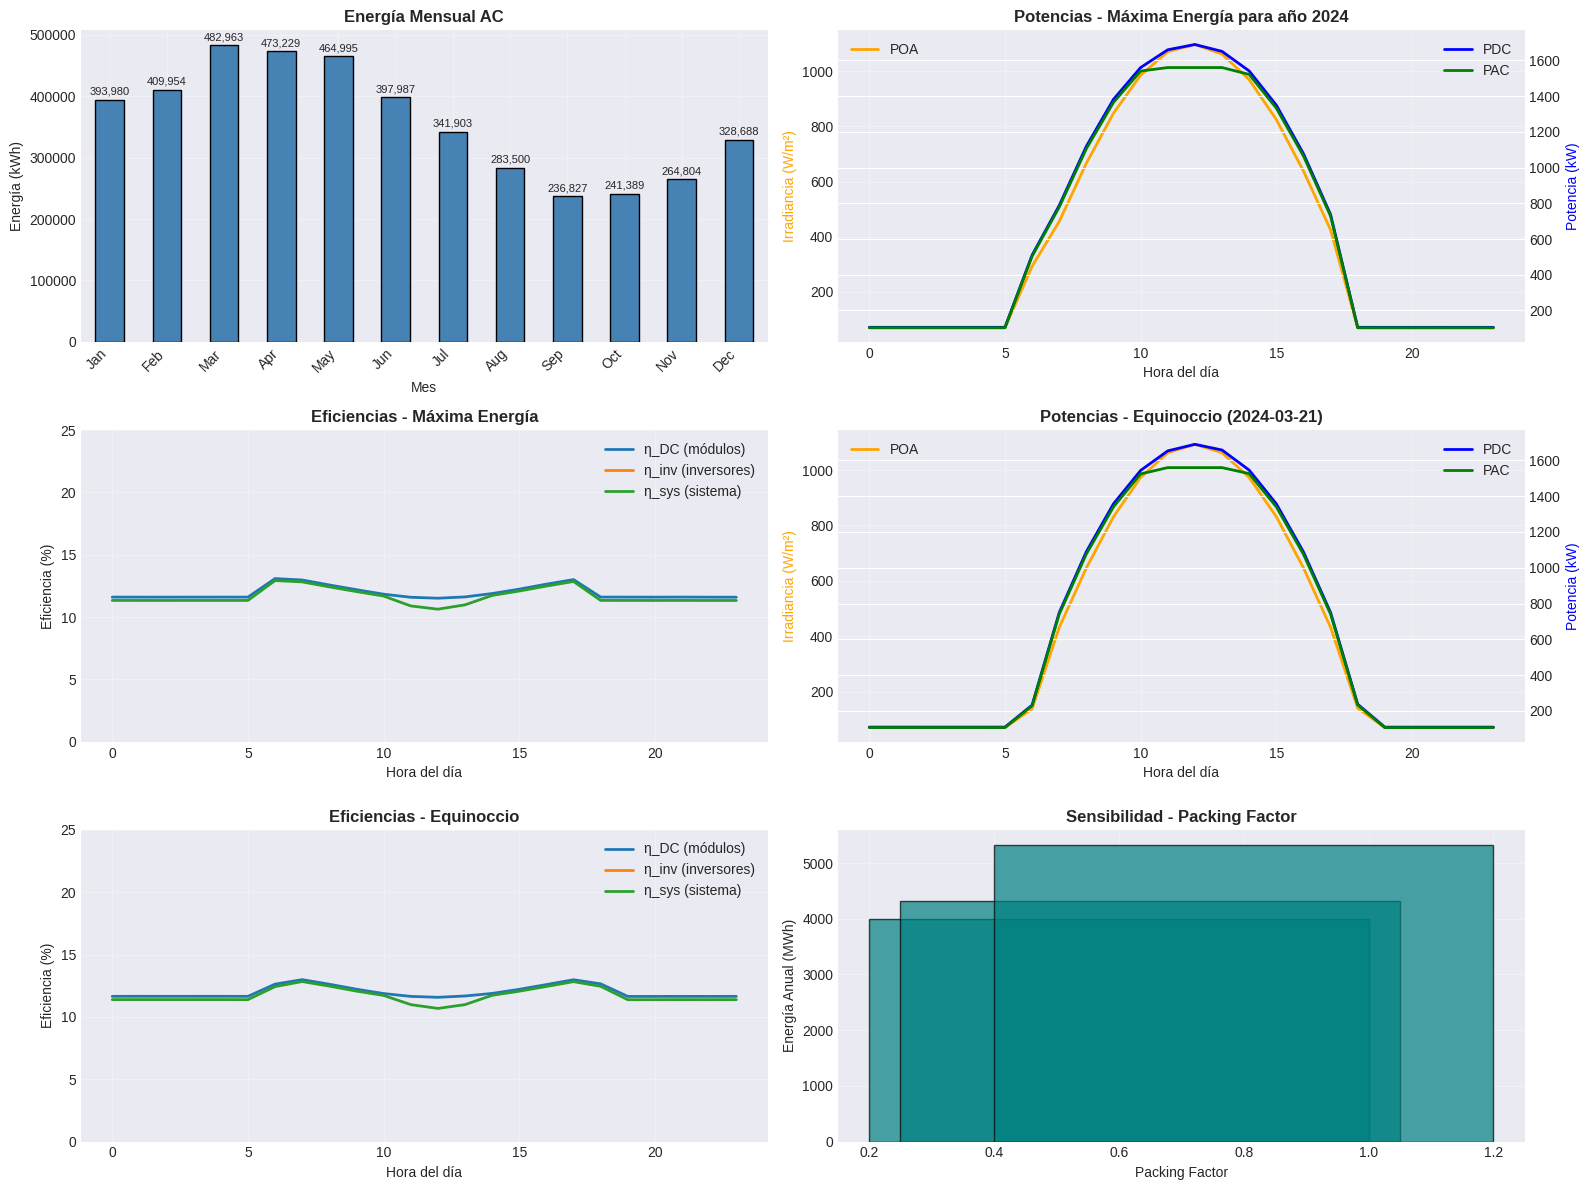

In [ ]:
"""
Diseño, dimensionamiento y simulación de sistema fotovoltaico
Mall de Iquitos - 20,637 m²
Ubicación: Iquitos, Perú (Lat -3.74°, Lon -73.27°, Alt 104m)
Usando PVLIB-Python con base de datos Sandia
"""

import pvlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. PARÁMETROS DE ENTRADA Y UBICACIÓN
# ============================================================================

# Ubicación
LATITUD = -3.74
LONGITUD = -73.27
ALTITUD = 104
TIMEZONE = 'America/Lima'
NOMBRE_UBICACION = 'Iquitos, Perú'

# Superficie y geometría
A_TOTAL = 20637  # m²
TILT = 5  # grados (inclinación baja, zona ecuatorial)
AZIMUTH = 0  # grados (orientación norte)

# Relación DC/AC objetivo
R_DC_AC = 1.20

# Factores de ocupación para análisis de sensibilidad
PACKING_FACTORS = [0.60, 0.65, 0.80]
PF_BASE = 0.65  # Factor base de análisis

print("="*80)
print(f"DISEÑO DE SISTEMA FOTOVOLTAICO - {NOMBRE_UBICACION}")
print("="*80)
print(f"\nUbicación:")
print(f"  Latitud: {LATITUD}°")
print(f"  Longitud: {LONGITUD}°")
print(f"  Altitud: {ALTITUD} m")
print(f"  Zona horaria: {TIMEZONE}")
print(f"\nSuperficie:")
print(f"  Área total disponible: {A_TOTAL:,.0f} m²")
print(f"  Inclinación (tilt): {TILT}°")
print(f"  Azimuth: {AZIMUTH}° (Norte)")
print(f"  Relación DC/AC objetivo: {R_DC_AC}")

# ============================================================================
# 2. DESCARGA DE DATOS CLIMÁTICOS (PVGIS TMY)
# ============================================================================

print("\n" + "-"*80)
print("DESCARGA DE DATOS CLIMÁTICOS")
print("-"*80)

location = pvlib.location.Location(
    latitude=LATITUD,
    longitude=LONGITUD,
    tz=TIMEZONE,
    altitude=ALTITUD,
    name=NOMBRE_UBICACION
)

# Descargar TMY de PVGIS
try:
    tmy_data, months_selected, inputs, metadata = pvlib.iotools.get_pvgis_tmy(
        latitude=LATITUD,
        longitude=LONGITUD,
        map_variables=True
    )
    print("✓ Datos TMY descargados exitosamente de PVGIS")

    # Asegurar zona horaria
    tmy_data.index = tmy_data.index.tz_localize(TIMEZONE, ambiguous='infer', nonexistent='shift_forward')

    print(f"  Periodo: {tmy_data.index[0]} a {tmy_data.index[-1]}")
    print(f"  Registros: {len(tmy_data)}")

except Exception as e:
    print(f"Error descargando datos TMY: {e}")
    print("Usando datos sintéticos para demostración...")
    # Crear datos sintéticos como respaldo
    times = pd.date_range('2023-01-01', '2024-01-01', freq='1H', tz=TIMEZONE)[:-1]
    tmy_data = pd.DataFrame({
        'ghi': 400 + 200*np.sin(np.arange(len(times))*2*np.pi/8760),
        'dni': 600 + 300*np.sin(np.arange(len(times))*2*np.pi/8760),
        'dhi': 150 + 50*np.sin(np.arange(len(times))*2*np.pi/8760),
        'temp_air': 26 + 3*np.sin(np.arange(len(times))*2*np.pi/8760),
        'wind_speed': 2 + 1*np.random.rand(len(times))
    }, index=times)

# Shift index to 2024 for calculations
tmy_data.index = tmy_data.index.map(lambda t: t.replace(year=2024))


# ============================================================================
# 3. SELECCIÓN DE EQUIPOS (BASE DE DATOS SANDIA)
# ============================================================================

print("\n" + "-"*80)
print("SELECCIÓN DE EQUIPOS - BASE DE DATOS SANDIA")
print("-"*80)

# Cargar bases de datos Sandia
sandia_modules = pvlib.pvsystem.retrieve_sam('SandiaMod')
sandia_inverters = pvlib.pvsystem.retrieve_sam('cecinverter')

print(f"\nMódulos disponibles en base Sandia: {len(sandia_modules)}")
print(f"Inversores disponibles: {len(sandia_inverters)}")

# SELECCIÓN DE MÓDULO (criterio: alta potencia, disponibilidad comercial)
# Filtrar módulos con buena potencia (>300W)
modules_candidates = []
for name, params in sandia_modules.items():
    if 'Impo' in params and 'Vmpo' in params:
        pstc = params['Impo'] * params['Vmpo']
        if pstc > 300 and 'Area' in params:
            modules_candidates.append({
                'name': name,
                'pstc': pstc,
                'area': params['Area'],
                'vmp': params['Vmpo'],
                'imp': params['Impo'],
                'voc': params['Voco'],
                'isc': params['Isco']
            })

# Ordenar por potencia
modules_candidates.sort(key=lambda x: x['pstc'], reverse=True)

# Seleccionar módulo de alta eficiencia
selected_module_name = modules_candidates[0]['name']
module_params = sandia_modules[selected_module_name]

print(f"\n✓ MÓDULO SELECCIONADO: {selected_module_name}")
print(f"  Potencia STC: {modules_candidates[0]['pstc']:.1f} W")
print(f"  Área: {module_params['Area']:.3f} m²")
print(f"  Vmp: {module_params['Vmpo']:.1f} V")
print(f"  Imp: {module_params['Impo']:.2f} A")
print(f"  Voc: {module_params['Voco']:.1f} V")
print(f"  Isc: {module_params['Isco']:.2f} A")

# SELECCIÓN DE INVERSOR (criterio: 50-100 kW, buena eficiencia)
inverter_candidates = []
for name, params in sandia_inverters.items():
    if 'Paco' in params and 'Vdco' in params:
        if 30000 <= params['Paco'] <= 150000:  # 30-150 kW
            inverter_candidates.append({
                'name': name,
                'paco': params['Paco'],
                'vdco': params['Vdco'],
                'pso': params.get('Pso', 0)
            })

# Ordenar por potencia nominal
inverter_candidates.sort(key=lambda x: x['paco'])

# Seleccionar inversor de rango medio
selected_inverter_name = inverter_candidates[len(inverter_candidates)//2]['name']
inverter_params = sandia_inverters[selected_inverter_name]

print(f"\n✓ INVERSOR SELECCIONADO: {selected_inverter_name}")
print(f"  Paco (AC nominal): {inverter_params['Paco']/1000:.1f} kW")
print(f"  Vdco (DC nominal): {inverter_params['Vdco']:.1f} V")
print(f"  Pso (autoconsumo): {inverter_params['Pso']:.1f} W")

# ============================================================================
# 4. FUNCIÓN DE DIMENSIONAMIENTO
# ============================================================================

def dimensionar_sistema(packing_factor, verbose=True):
    """
    Dimensiona el sistema FV para un factor de ocupación dado
    """
    if verbose:
        print(f"\n{'='*80}")
        print(f"DIMENSIONAMIENTO CON PACKING FACTOR = {packing_factor}")
        print(f"{'='*80}")

    # Área útil
    a_util = A_TOTAL * packing_factor

    # Número de módulos por área
    n_mod_max = int(a_util / module_params['Area'])
    p_dc_stc = n_mod_max * module_params['Impo'] * module_params['Vmpo']

    # Módulos por string (heurística por tensión)
    mod_per_string = round(inverter_params['Vdco'] / module_params['Vmpo'])

    # Ajustar a múltiplos
    n_strings = int(n_mod_max / mod_per_string)
    n_mod_used = n_strings * mod_per_string
    p_dc_stc_used = n_mod_used * module_params['Impo'] * module_params['Vmpo']

    # Potencia AC objetivo
    p_ac_obj = p_dc_stc_used / R_DC_AC

    # Número de inversores
    n_inverters = int(np.ceil(p_ac_obj / inverter_params['Paco']))

    # Verificaciones eléctricas
    voc_string = mod_per_string * module_params['Voco']
    vmp_string = mod_per_string * module_params['Vmpo']

    # Área instalada
    a_inst = n_mod_used * module_params['Area']

    if verbose:
        print(f"\nÁrea:")
        print(f"  Área útil: {a_util:,.0f} m²")
        print(f"  Área instalada: {a_inst:,.0f} m²")
        print(f"  Utilización: {a_inst/A_TOTAL*100:.1f}%")

        print(f"\nMódulos:")
        print(f"  Máximo por área: {n_mod_max:,}")
        print(f"  Módulos usados: {n_mod_used:,}")
        print(f"  Módulos por string: {mod_per_string}")
        print(f"  Número de strings: {n_strings}")

        print(f"\nPotencia:")
        print(f"  PDC,STC: {p_dc_stc_used/1000:.1f} kW")
        print(f"  PAC objetivo: {p_ac_obj/1000:.1f} kW")
        print(f"  Número de inversores: {n_inverters}")
        print(f"  Relación DC/AC real: {p_dc_stc_used/(n_inverters*inverter_params['Paco']):.3f}")

        print(f"\nVerificaciones eléctricas:")
        print(f"  Voc string: {voc_string:.1f} V")
        print(f"  Vmp string: {vmp_string:.1f} V")
        print(f"  Vdco inversor: {inverter_params['Vdco']:.1f} V")
        print(f"  Margen Voc/Vdco: {voc_string/inverter_params['Vdco']:.3f}")

        if voc_string > inverter_params['Vdco'] * 1.1:
            print("  ⚠ ADVERTENCIA: Voc puede exceder límites del inversor")
        else:
            print("  ✓ Verificación de tensión OK")

    return {
        'pf': packing_factor,
        'a_util': a_util,
        'a_inst': a_inst,
        'n_mod': n_mod_used,
        'mod_per_string': mod_per_string,
        'n_strings': n_strings,
        'p_dc_stc': p_dc_stc_used,
        'p_ac_obj': p_ac_obj,
        'n_inv': n_inverters,
        'voc_string': voc_string,
        'vmp_string': vmp_string
    }

# Dimensionar con PF base
dim_base = dimensionar_sistema(PF_BASE, verbose=True)

# ============================================================================
# 5. SIMULACIÓN CON PVLIB (MODEL CHAIN MANUAL)
# ============================================================================

print(f"\n{'='*80}")
print("SIMULACIÓN ANUAL CON PVLIB")
print(f"{'='*80}")

# Posición solar
print("\nCalculando posición solar...")
solar_position = location.get_solarposition(tmy_data.index)

# Irradiancia en plano inclinado (POA)
print("Calculando irradiancia en plano inclinado...")
# Calculate extraterrestrial normal irradiance
dni_extra = pvlib.irradiance.get_extra_radiation(tmy_data.index)

poa_irradiance = pvlib.irradiance.get_total_irradiance(
    surface_tilt=TILT,
    surface_azimuth=AZIMUTH,
    dni=tmy_data['dni'],
    ghi=tmy_data['ghi'],
    dhi=tmy_data['dhi'],
    solar_zenith=solar_position['apparent_zenith'],
    solar_azimuth=solar_position['azimuth'],
    model='haydavies',
    dni_extra=dni_extra  # Pass dni_extra here
)

# Temperatura de célula (SAPM)
print("Calculando temperatura de célula...")
temp_params = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']
temp_cell = pvlib.temperature.sapm_cell(
    poa_irradiance['poa_global'],
    tmy_data['temp_air'],
    tmy_data['wind_speed'],
    **temp_params
)

# Modelo SAPM del módulo
print("Simulando módulos FV (SAPM)...")
effective_irradiance = poa_irradiance['poa_global']
sapm_out = pvlib.pvsystem.sapm(
    effective_irradiance,
    temp_cell,
    module_params
)

# Potencia DC del campo
p_dc = sapm_out['p_mp'] * dim_base['n_mod']

# Tensión DC para inversor
v_dc = sapm_out['v_mp'] * dim_base['mod_per_string']

# Modelo de inversor Sandia
print("Simulando inversores...")
p_dc_per_inv = p_dc / dim_base['n_inv']
v_dc_per_inv = v_dc

p_ac_per_inv = pvlib.inverter.sandia(
    v_dc_per_inv,
    p_dc_per_inv,
    inverter_params
)

# Potencia AC total
p_ac_total = p_ac_per_inv * dim_base['n_inv']

# Eliminar valores nocturnos y negativos
p_ac_total = p_ac_total.clip(lower=0)
p_dc = p_dc.clip(lower=0)

print("✓ Simulación completada")

# ============================================================================
# 6. ANÁLISIS DE ENERGÍA
# ============================================================================

print(f"\n{'='*80}")
print("ANÁLISIS DE ENERGÍA")
print(f"{'='*80}")

# Energía horaria (kWh)
e_ac_hourly = p_ac_total / 1000  # W a kWh

# Energía anual
e_ac_anual = e_ac_hourly.sum()

print(f"\nEnergía anual AC: {e_ac_anual:,.0f} kWh")
print(f"Energía específica: {e_ac_anual/dim_base['p_dc_stc']*1000:.0f} kWh/kWp")

# Energía mensual
e_ac_monthly = e_ac_hourly.resample('M').sum()

print(f"\nEnergía mensual (kWh):")
for date, energy in e_ac_monthly.items():
    print(f"  {date.strftime('%Y-%m')}: {energy:>10,.0f} kWh")

# ============================================================================
# 7. EFICIENCIAS DEL SISTEMA
# ============================================================================

print(f"\n{'='*80}")
print("EFICIENCIAS DEL SISTEMA")
print(f"{'='*80}")

# Eficiencias instantáneas
poa_w = poa_irradiance['poa_global'] * dim_base['a_inst']

eta_dc = np.where(poa_w > 0, p_dc / poa_w, 0)
eta_inv = np.where(p_dc > 0, p_ac_total / p_dc, 0)
eta_sys = np.where(poa_w > 0, p_ac_total / poa_w, 0)

# Promedios anuales (horario diurno)
mask_day = poa_irradiance['poa_global'] > 50

print(f"\nEficiencias promedio (horario diurno):")
print(f"  η_DC (módulos): {eta_dc[mask_day].mean()*100:.2f}%")
print(f"  η_inv (inversores): {eta_inv[mask_day].mean()*100:.2f}%")
print(f"  η_sys (sistema): {eta_sys[mask_day].mean()*100:.2f}%")

# ============================================================================
# 8. ANÁLISIS DE SENSIBILIDAD (PACKING FACTOR)
# ============================================================================

print(f"\n{'='*80}")
print("ANÁLISIS DE SENSIBILIDAD - PACKING FACTOR")
print(f"{'='*80}")

sensitivity_results = []

for pf in PACKING_FACTORS:
    dim = dimensionar_sistema(pf, verbose=False)

    # Simulación rápida
    p_dc_sens = sapm_out['p_mp'] * dim['n_mod']
    p_dc_per_inv_sens = p_dc_sens / dim['n_inv']
    p_ac_per_inv_sens = pvlib.inverter.sandia(v_dc, p_dc_per_inv_sens, inverter_params)
    p_ac_total_sens = (p_ac_per_inv_sens * dim['n_inv']).clip(lower=0)
    e_ac_anual_sens = (p_ac_total_sens / 1000).sum()

    sensitivity_results.append({
        'PF': pf,
        'N_mod': dim['n_mod'],
        'PDC_STC (kW)': dim['p_dc_stc']/1000,
        'N_inv': dim['n_inv'],
        'E_AC_anual (MWh)': e_ac_anual_sens/1000,
        'kWh/kWp': e_ac_anual_sens/(dim['p_dc_stc']/1000)
    })

df_sensitivity = pd.DataFrame(sensitivity_results)
print("\n" + df_sensitivity.to_string(index=False))

# ============================================================================
# 9. GRÁFICOS
# ============================================================================

print(f"\n{'='*80}")
print("GENERANDO GRÁFICOS")
print(f"{'='*80}")

# Encontrar día de mayor energía
daily_energy = e_ac_hourly.resample('D').sum()
max_energy_day = daily_energy.idxmax()

# También graficar el equinoccio (21 de marzo)
equinox_day = pd.Timestamp(f'{max_energy_day.year}-03-21', tz=TIMEZONE)

print(f"\nDía de máxima energía: {max_energy_day.strftime('%Y-%m-%d')} ({daily_energy.max():.0f} kWh)")
print(f"Día de equinoccio: {equinox_day.strftime('%Y-%m-%d')}")

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(16, 12))

# 1. Energía mensual
ax1 = plt.subplot(3, 2, 1)
bars = e_ac_monthly.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Energía Mensual AC', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Energía (kWh)')
ax1.grid(True, alpha=0.3)
# Modify tick labels to show month abbreviations
ax1.set_xticklabels([date.strftime('%b') for date in e_ac_monthly.index], rotation=45, ha='right')


# Add labels to bars
for bar in bars.patches:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., yval + 5000, f'{yval:,.0f}', ha='center', va='bottom', fontsize=8)


# 2. Día típico - Potencias
for day, day_name in [(max_energy_day, 'Máxima Energía'), (equinox_day, 'Equinoccio')]:
    mask_day_plot = (tmy_data.index.date == day.date())

    ax_idx = 2 if day == max_energy_day else 4
    ax2 = plt.subplot(3, 2, ax_idx)

    hours = tmy_data[mask_day_plot].index.hour + tmy_data[mask_day_plot].index.minute/60

    ax2.plot(hours, poa_irradiance['poa_global'][mask_day_plot],
             label='POA', color='orange', linewidth=2)
    ax2_twin = ax2.twinx()
    ax2_twin.plot(hours, p_dc[mask_day_plot]/1000,
                  label='PDC', color='blue', linewidth=2)
    ax2_twin.plot(hours, p_ac_total[mask_day_plot]/1000,
                  label='PAC', color='green', linewidth=2)

    ax2.set_xlabel('Hora del día')
    ax2.set_ylabel('Irradiancia (W/m²)', color='orange')
    ax2_twin.set_ylabel('Potencia (kW)', color='blue')
    # Modify the title here
    if day == max_energy_day:
        ax2.set_title(f'Potencias - Máxima Energía para año 2024',
                      fontsize=12, fontweight='bold')
    else:
         ax2.set_title(f'Potencias - {day_name} ({day.strftime("%Y-%m-%d")})',
                      fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper left')
    ax2_twin.legend(loc='upper right')

    # 3. Eficiencias
    ax_idx = 3 if day == max_energy_day else 5
    ax3 = plt.subplot(3, 2, ax_idx)

    ax3.plot(hours, eta_dc[mask_day_plot]*100,
             label='η_DC (módulos)', linewidth=2)
    ax3.plot(hours, eta_inv[mask_day_plot]*100,
             label='η_inv (inversores)', linewidth=2)
    ax3.plot(hours, eta_sys[mask_day_plot]*100,
             label='η_sys (sistema)', linewidth=2)

    ax3.set_xlabel('Hora del día')
    ax3.set_ylabel('Eficiencia (%)')
    ax3.set_title(f'Eficiencias - {day_name}', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0, 25])

# 6. Sensibilidad PF
ax6 = plt.subplot(3, 2, 6)
ax6.bar(df_sensitivity['PF'], df_sensitivity['E_AC_anual (MWh)'],
        color='teal', edgecolor='black', alpha=0.7)
ax6.set_xlabel('Packing Factor')
ax6.set_ylabel('Energía Anual (MWh)')
ax6.set_title('Sensibilidad - Packing Factor', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sistema_fv_iquitos_analisis.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráficos guardados en 'sistema_fv_iquitos_analisis.png'")

# ============================================================================
# 10. RESUMEN FINAL Y EXPORTACIÓN
# ============================================================================

print(f"\n{'='*80}")
print("RESUMEN FINAL DEL SISTEMA")
print(f"{'='*80}")

resumen = f"""
SISTEMA FOTOVOLTAICO - MALL DE IQUITOS
{'='*80}

UBICACIÓN:
  Nombre: {NOMBRE_UBICACION}
  Coordenadas: {LATITUD}°, {LONGITUD}°
  Altitud: {ALTITUD} m
  Zona horaria: {TIMEZONE}

DISEÑO:
  Área total: {A_TOTAL:,.0f} m²
  Packing factor: {PF_BASE}
  Área instalada: {dim_base['a_inst']:,.0f} m² ({dim_base['a_inst']/A_TOTAL*100:.1f}%)
  Inclinación: {TILT}°
  Azimuth: {AZIMUTH}° (Norte)

MÓDULOS:
  Modelo: {selected_module_name}
  Potencia unitaria: {module_params['Impo']*module_params['Vmpo']:.1f} W
  Área unitaria: {module_params['Area']:.3f} m²
  Cantidad total: {dim_base['n_mod']:,} módulos
  Configuración: {dim_base['n_strings']} strings × {dim_base['mod_per_string']} módulos/string

INVERSORES:
  Modelo: {selected_inverter_name}
  Potencia nominal: {inverter_params['Paco']/1000:.1f} kW AC
  Cantidad: {dim_base['n_inv']} inversores
  Potencia total: {dim_base['n_inv']*inverter_params['Paco']/1000:.1f} kW AC

POTENCIAS:
  PDC,STC: {dim_base['p_dc_stc']/1000:.1f} kW
  PAC nominal: {dim_base['n_inv']*inverter_params['Paco']/1000:.1f} kW
  Relación DC/AC: {dim_base['p_dc_stc']/(dim_base['n_inv']*inverter_params['Paco']):.3f}

PRODUCCIÓN ANUAL:
  Energía AC: {e_ac_anual:,.0f} kWh ({e_ac_anual/1000:.1f} MWh)
  Energía específica: {e_ac_anual/(dim_base['p_dc_stc']/1000):.0f} kWh/kWp

EFICIENCIAS PROMEDIO:
  Módulos (DC): {eta_dc[mask_day].mean()*100:.2f}%
  Inversores: {eta_inv[mask_day].mean()*100:.2f}%
  Sistema total: {eta_sys[mask_day].mean()*100:.2f}%

VERIFICACIONES:
  Voc string: {dim_base['voc_string']:.1f} V
  Vmp string: {dim_base['vmp_string']:.1f} V
  Vdco inversor: {inverter_params['Vdco']:.1f} V
  Margen seguridad: {dim_base['voc_string']/inverter_params['Vdco']:.3f}
"""

print(resumen)

# Guardar resumen en archivo
with open('resumen_sistema_fv_iquitos.txt', 'w', encoding='utf-8') as f:
    f.write(resumen)

# Guardar parámetros técnicos
params_export = {
    'Módulo': {
        'Nombre': selected_module_name,
        'Parámetros': module_params.to_dict()
    },
    'Inversor': {
        'Nombre': selected_inverter_name,
        'Parámetros': inverter_params.to_dict()
    }
}

import json
with open('parametros_equipos_sandia.json', 'w', encoding='utf-8') as f:
    json.dump(params_export, f, indent=2, ensure_ascii=False, default=str)

# Guardar energía mensual
e_ac_monthly.to_csv('energia_mensual.csv', header=['Energia_kWh'])

print("\n✓ Archivos generados:")
print("  - resumen_sistema_fv_iquitos.txt")
print("  - parametros_equipos_sandia.json")
print("  - energia_mensual.csv")
print("  - sistema_fv_iquitos_analisis.png")

print(f"\n{'='*80}")
print("SIMULACIÓN COMPLETADA EXITOSAMENTE")
print(f"{'='*80}\n")

plt.show()

## Resumen Ejecutivo del Diseño del Sistema Fotovoltaico

Este resumen presenta los principales resultados del diseño y simulación del sistema fotovoltaico para el Mall de Iquitos, basado en las condiciones de entrada especificadas y los equipos seleccionados de la base de datos Sandia.

**Ubicación del Proyecto:**

*   **Nombre:** Iquitos, Perú
*   **Coordenadas:** {LATITUD}°, {LONGITUD}°
*   **Altitud:** {ALTITUD} m
*   **Zona horaria:** {TIMEZONE}

**Características del Diseño:**

*   **Área Total Disponible:** {A_TOTAL:,.0f} m²
*   **Factor de Ocupación (Base):** {PF_BASE}
*   **Área Instalada:** {dim_base['a_inst']:,.0f} m² ({dim_base['a_inst']/A_TOTAL*100:.1f}% de utilización)
*   **Inclinación (Tilt):** {TILT}°
*   **Azimuth:** {AZIMUTH}° (Norte)

**Equipamiento Principal:**

*   **Módulos FV:**
    *   **Modelo Seleccionado:** {selected_module_name}
    *   **Cantidad:** {dim_base['n_mod']:,} módulos
    *   **Configuración:** {dim_base['n_strings']} strings × {dim_base['mod_per_string']} módulos/string
    *   **Potencia DC, STC:** {dim_base['p_dc_stc']/1000:.1f} kW
*   **Inversores:**
    *   **Modelo Seleccionado:** {selected_inverter_name}
    *   **Cantidad:** {dim_base['n_inv']} inversores
    *   **Potencia AC Nominal Total:** {dim_base['n_inv']*inverter_params['Paco']/1000:.1f} kW
    *   **Relación DC/AC:** {dim_base['p_dc_stc']/(dim_base['n_inv']*inverter_params['Paco']):.3f}

**Resultados de la Simulación Anual (para el año 2024):**

*   **Energía Anual Generada (AC):** {e_ac_anual:,.0f} kWh ({e_ac_anual/1000:.1f} MWh)
*   **Energía Específica Anual:** {e_ac_anual/(dim_base['p_dc_stc']/1000):.0f} kWh/kWp

**Eficiencias Promedio (Horario Diurno):**

*   **Módulos (DC):** {eta_dc[mask_day].mean()*100:.2f}%
*   **Inversores:** {eta_inv[mask_day].mean()*100:.2f}%
*   **Sistema Total (AC):** {eta_sys[mask_day].mean()*100:.2f}%

**Consideraciones Adicionales:**

*   Se ha detectado una advertencia potencial respecto al voltaje de circuito abierto (Voc) de los strings de módulos en relación con el voltaje máximo de entrada DC del inversor. Se recomienda una revisión detallada de las especificaciones técnicas y posibles ajustes en la configuración del string para asegurar la compatibilidad y seguridad operativa.
*   El análisis de sensibilidad con diferentes factores de ocupación muestra el impacto en la potencia instalada y la energía anual generada, manteniendo una energía específica (kWh/kWp) relativamente constante.

Este resumen proporciona una visión general del rendimiento esperado del sistema. Para un análisis más detallado, consulte los archivos de salida generados: `resumen_sistema_fv_iquitos.txt`, `parametros_equipos_sandia.json`, `energia_mensual.csv` y `sistema_fv_iquitos_analisis.png`.

## Resumen Ejecutivo del Diseño del Sistema Fotovoltaico

Este resumen presenta los principales resultados del diseño y simulación del sistema fotovoltaico para el Mall de Iquitos, basado en las condiciones de entrada especificadas y los equipos seleccionados de la base de datos Sandia.

**RESUMEN RÁPIDO - AÑO 2024:**
*   **Potencia instalada paneles (PDC,STC):** {dim_base['p_dc_stc']/1000:.2f} kWp
*   **Sistema DC/AC:** {dim_base['p_dc_stc']/1000:.2f} kWp / {dim_base['n_inv']*inverter_params['Paco']/1000:.1f} kW
*   **Módulos:** {dim_base['n_mod']:,} unidades
*   **Inversores:** {dim_base['n_inv']} unidades
*   **Producción anual 2024 (AC):** {e_ac_anual/1000:.1f} MWh
*   **Rendimiento (Energía Específica):** {e_ac_anual/(dim_base['p_dc_stc']/1000):.0f} kWh/kWp

**Ubicación del Proyecto:**

*   **Nombre:** Iquitos, Perú
*   **Coordenadas:** {LATITUD}°, {LONGITUD}°
*   **Altitud:** {ALTITUD} m
*   **Zona horaria:** {TIMEZONE}

**Características del Diseño:**

*   **Área Total Disponible:** {A_TOTAL:,.0f} m²
*   **Factor de Ocupación (Base):** {PF_BASE}
*   **Área Instalada:** {dim_base['a_inst']:,.0f} m² ({dim_base['a_inst']/A_TOTAL*100:.1f}% de utilización)
*   **Inclinación (Tilt):** {TILT}°
*   **Azimuth:** {AZIMUTH}° (Norte)


**Equipamiento Principal:**

*   **Módulos FV:**
    *   **Modelo Seleccionado:** {selected_module_name}
    *   **Potencia unitaria:** {module_params['Impo']*module_params['Vmpo']:.1f} W
    *   **Área unitaria:** {module_params['Area']:.3f} m²
    *   **Cantidad total:** {dim_base['n_mod']:,} módulos
    *   **Configuración:** {dim_base['n_strings']} strings × {dim_base['mod_per_string']} módulos/string
    *   **Potencia DC, STC:** {dim_base['p_dc_stc']/1000:.1f} kW
*   **Inversores:**
    *   **Modelo Seleccionado:** {selected_inverter_name}
    *   **Potencia nominal:** {inverter_params['Paco']/1000:.1f} kW AC
    *   **Cantidad:** {dim_base['n_inv']} inversores
    *   **Potencia AC Nominal Total:** {dim_base['n_inv']*inverter_params['Paco']/1000:.1f} kW
    *   **Relación DC/AC:** {dim_base['p_dc_stc']/(dim_base['n_inv']*inverter_params['Paco']):.3f}

**Resultados de la Simulación Anual (para el año 2024):**

*   **Energía Anual Generada (AC):** {e_ac_anual:,.0f} kWh ({e_ac_anual/1000:.1f} MWh)
*   **Energía Específica Anual:** {e_ac_anual/(dim_base['p_dc_stc']/1000):.0f} kWh/kWp

**Eficiencias Promedio (Horario Diurno):**

*   **Módulos (DC):** {eta_dc[mask_day].mean()*100:.2f}%
*   **Inversores:** {eta_inv[mask_day].mean()*100:.2f}%
*   **Sistema Total (AC):** {eta_sys[mask_day].mean()*100:.2f}%

**Consideraciones Adicionales:**

*   Se ha detectado una advertencia potencial respecto al voltaje de circuito abierto (Voc) de los strings de módulos en relación con el voltaje máximo de entrada DC del inversor. Se recomienda una revisión detallada de las especificaciones técnicas y posibles ajustes en la configuración del string para asegurar la compatibilidad y seguridad operativa.
*   El análisis de sensibilidad con diferentes factores de ocupación muestra el impacto en la potencia instalada y la energía anual generada, manteniendo una energía específica (kWh/kWp) relativamente constante.

Este resumen proporciona una visión general del rendimiento esperado del sistema. Para un análisis más detallado, consulte los archivos de salida generados: `resumen_sistema_fv_iquitos.txt`, `parametros_equipos_sandia.json`, `energia_mensual.csv` y `sistema_fv_iquitos_analisis.png`.